In [83]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def process(Subject, weight, folder_dir):
        data = ['Standing', 'NoExo1', 'NoExo2', 'NoAssi', '20p40ms','20p110ms', '20p180ms','20p250ms', '20p320ms']
        file_paths = {d: f"{folder_dir}\\{d}.xlsx" for d in data}
        
        powers = {}
        for key, path in file_paths.items():
            if os.path.exists(path):
                print(f"Processing {key} from {path}")
                df = pd.read_excel(path)
                powers[key] = calculate_power(df, weight, key)
            else:
                print(f"File {path} not found. Skipping {key}.")
        return powers
    

def calculate_power(df, weight, trial_name):
        time_raw = df['t'].iloc[2:].to_numpy()
        t = np.array([tt.minute * 60 + tt.second for tt in time_raw])

        vo2 = pd.to_numeric(df['VO2'].iloc[2:], errors='coerce').to_numpy()
        vco2 = pd.to_numeric(df['VCO2'].iloc[2:], errors='coerce').to_numpy()

        # respiratory response in Watts
        Watt = 0.278 * vo2 + 0.075 * vco2
        Watt_per_kg = Watt / weight

        # valid samples only
        valid_basic = ~np.isnan(t) & ~np.isnan(vo2) & ~np.isnan(vco2)
        
        if trial_name == 'Standing':
            valid = valid_basic
        else:
            mask = (t >= 240) & (t <= 360)
            valid = valid_basic & mask

        if np.sum(valid) == 0:
            print(f"No valid data for {trial_name}.")
            return np.nan

        Watt_per_kg_mean = np.mean(Watt_per_kg[valid])

        return Watt_per_kg_mean

Processing Standing from C:\Users\Vicon-OEM\Desktop\Jimin K5\SUB03\LG\Standing.xlsx
Processing NoExo1 from C:\Users\Vicon-OEM\Desktop\Jimin K5\SUB03\LG\NoExo1.xlsx
Processing NoExo2 from C:\Users\Vicon-OEM\Desktop\Jimin K5\SUB03\LG\NoExo2.xlsx
Processing NoAssi from C:\Users\Vicon-OEM\Desktop\Jimin K5\SUB03\LG\NoAssi.xlsx
Processing 20p40ms from C:\Users\Vicon-OEM\Desktop\Jimin K5\SUB03\LG\20p40ms.xlsx
Processing 20p110ms from C:\Users\Vicon-OEM\Desktop\Jimin K5\SUB03\LG\20p110ms.xlsx
Processing 20p180ms from C:\Users\Vicon-OEM\Desktop\Jimin K5\SUB03\LG\20p180ms.xlsx
Processing 20p250ms from C:\Users\Vicon-OEM\Desktop\Jimin K5\SUB03\LG\20p250ms.xlsx
Processing 20p320ms from C:\Users\Vicon-OEM\Desktop\Jimin K5\SUB03\LG\20p320ms.xlsx
Ilseung's Power Outputs (W/kg): {'Standing': 1.1879568548547714, 'NoExo1': 4.745679434315518, 'NoExo2': 5.497881699157896, 'NoAssi': 4.967139343025849, '20p40ms': 4.637164518574748, '20p110ms': 4.71239988354132, '20p180ms': 4.428425124807497, '20p250ms': 4.5

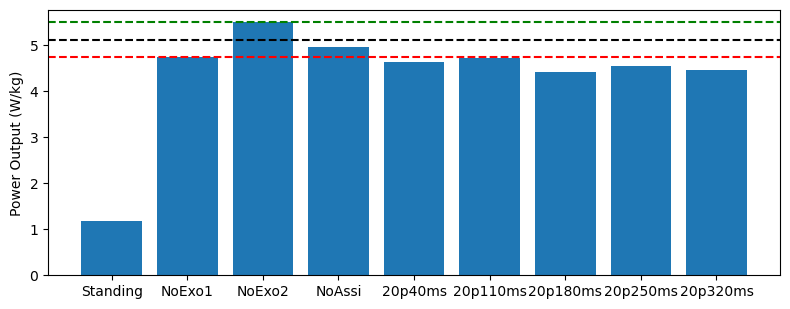

In [84]:
Subject = "SUB03"
weight = 61.9

folder_dir = rf"C:\Users\Vicon-OEM\Desktop\Jimin K5\{Subject}\LG"
# folder_dir = rf"C:\Users\Vicon-OEM\Desktop\Jimin K5\{Subject}\RA"
# folder_dir = rf"C:\Users\Vicon-OEM\Desktop\Jimin K5\{Subject}\RD"

powers = process(Subject, weight, folder_dir)

print("Ilseung's Power Outputs (W/kg):", powers)

conditions_to_plot = ['Standing', 'NoExo1', 'NoExo2', 'NoAssi', '20p40ms','20p110ms', '20p180ms','20p250ms', '20p320ms']
available_conditions = [condition for condition in conditions_to_plot if condition in powers]
available_powers = [powers[condition] for condition in available_conditions]

if available_conditions:
    plt.figure(figsize=(8, 6))
    plt.subplot(2, 1, 1)
    plt.bar(available_conditions, available_powers)
    plt.axhline(y=powers['NoExo1'], color='r', linestyle='--', label='NoExo1')
    plt.axhline(y=powers['NoExo2'], color='g', linestyle='--', label='NoExo2')
    plt.axhline(y=(powers['NoExo2']+powers['NoExo1'])/2, color='black', linestyle='--')
    plt.ylabel('Power Output (W/kg)')
    # plt.ylim([6, 10])
    plt.tight_layout()
    plt.show()
else:
    print("No matching conditions were found to plot.")